# 📚 Seaborn Basics: countplot / barplot / lineplot / heatmap
> Section 10 of the Data Visualization curriculum (Matplotlib → Seaborn → Plotly → Tableau)
> 데이터 시각화 커리큘럼 섹션 10 (Matplotlib → Seaborn → Plotly → Tableau)

---
# 🎯 Learning Objective (학습 목표)
Today I want to learn / 오늘 배우고 싶은 것:
- [x] Understand what Seaborn is and how it relates to Matplotlib  
Seaborn이 무엇이고 Matplotlib과 어떤 관계인지 이해하기
- [x] Build `countplot`, `barplot`, `lineplot`, and `heatmap` charts with automatic aggregation  
자동 집계 기능을 가진 countplot, barplot, lineplot, heatmap 차트 만들기
- [x] Apply these charts to real Business Analyst scenarios (tiers, channel comparison, order patterns)  
고객 등급, 채널 비교, 주문 패턴 등 실제 BA 시나리오에 이 차트들 적용하기

---
# 🧠 Concept (개념)

## What is it? (이것은 무엇인가?)
*(Explain it in your own words.)*

**EN:** Seaborn is a statistical data visualization library built on top of Matplotlib. It isn't a new engine — it's a higher-level toolkit that makes Matplotlib faster and easier to use. Every Seaborn function still creates and returns a Matplotlib `Axes` object under the hood, which is why Matplotlib syntax you already know (`ax.set_title()`, `ax.grid()`, `plt.tight_layout()`) keeps working on Seaborn charts.

**KR:** Seaborn은 Matplotlib 위에 구축된 통계 시각화 라이브러리입니다. "새로운 엔진"이 아니라 "Matplotlib을 더 편하게 쓰기 위한 상위 도구"에 가깝습니다. Seaborn 함수도 결국 내부적으로 Matplotlib의 `Axes`를 만들고 반환하기 때문에, 이미 배운 `ax.set_title()`, `ax.grid()`, `plt.tight_layout()` 같은 Matplotlib 문법을 그대로 이어서 사용할 수 있습니다.

### Matplotlib vs Seaborn (비교)

| Aspect / 항목 | Matplotlib | Seaborn |
|---|---|---|
| Data input<br>데이터 입력 | Pass lists/arrays directly to `x=`, `y=`<br>리스트·배열을 직접 x=, y=에 전달 | Pass a whole Pandas DataFrame, point to columns with `x='col'`<br>DataFrame 통째로 넘기고 x='컬럼명'으로 지정 |
| Aggregation<br>집계 | You compute `groupby()`/`value_counts()` yourself first<br>groupby(), value_counts()를 직접 계산 후 그려야 함 | The function aggregates automatically (count, mean, ...)<br>함수가 자동으로 집계(개수, 평균 등)까지 계산 |
| Statistics<br>통계 정보 | You compute confidence intervals / regression lines yourself<br>신뢰구간·회귀선을 직접 계산해야 함 | Built-in `errorbar`, regression lines, etc.<br>errorbar, 회귀선 등 통계 기능이 내장 |
| Default style<br>기본 스타일 | Plain, needs manual styling<br>투박함(직접 꾸며야 함) | Polished theme out of the box<br>처음부터 미려한 기본 테마 |
| Fine customization<br>세밀한 커스터마이징 | Full manual control<br>모든 것을 직접 제어 | Still returns a Matplotlib `Axes`, so `ax.set_xlabel()` etc. still work<br>결국 Matplotlib Axes를 반환하므로 Matplotlib 문법 그대로 병행 사용 |

## Why do we use it? (왜 사용하는가?)
*(When is it useful?)*

**EN:** Seaborn removes the manual aggregation and styling steps Matplotlib requires. Instead of computing `value_counts()` or `groupby().mean()` yourself and feeding the numbers into `ax.bar()`, you pass a whole Pandas DataFrame and just name the columns — Seaborn counts, averages, and even adds confidence intervals automatically. It also ships with a more polished default look, so "quick" charts already look presentation-ready.

**KR:** Seaborn은 Matplotlib이 요구하는 수동 집계·스타일링 단계를 없애줍니다. `value_counts()`나 `groupby().mean()`을 직접 계산해서 `ax.bar()`에 넘기는 대신, Pandas DataFrame 전체를 넘기고 컬럼명만 지정하면 Seaborn이 개수·평균·신뢰구간까지 자동으로 계산해줍니다. 기본 테마도 훨씬 미려해서, "빠르게" 그린 차트도 이미 발표 수준의 완성도를 갖춥니다.

## When is it used in Business Analytics? (비즈니스 분석에서 언제 사용되는가?)
*(Real-world use case)*

**EN:** Anywhere you need to go from a raw, row-per-record table straight to an aggregated chart without writing separate aggregation code: counting customers per membership tier, comparing average order value across channels with a confidence interval, tracking weekly sales trends across many stores, or spotting order-volume hot spots across a day-of-week × time-of-day grid.

**KR:** 별도의 집계 코드 없이 "한 행 = 한 관측치"인 원본 데이터에서 곧바로 집계된 차트로 가고 싶을 때 어디서나 사용됩니다: 등급별 고객 수 세기, 채널별 평균 주문금액을 신뢰구간과 함께 비교하기, 여러 지점의 주간 매출 추이 추적하기, 요일×시간대 격자에서 주문량이 몰리는 구간 찾기 등입니다.

---
# 📝 Syntax (문법)

## Basic Syntax (기본 문법)

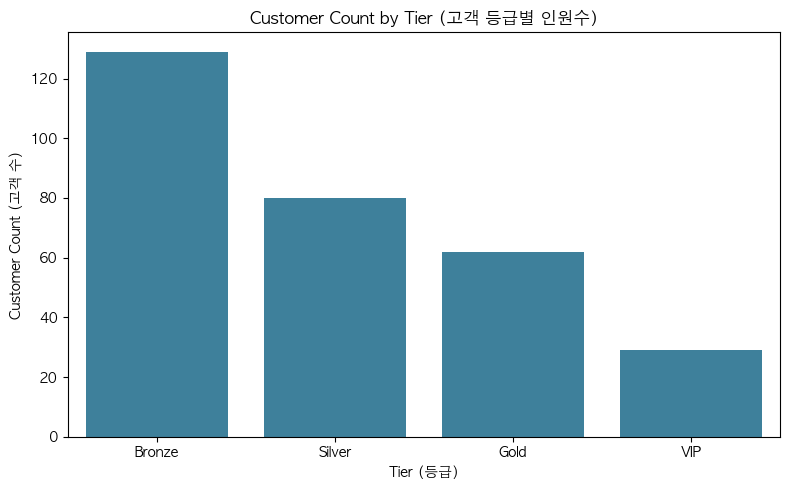

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Korean font setup so Korean labels render correctly
# Windows: 'Malgun Gothic', macOS: 'AppleGothic', Linux: 'AppleGothic'
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# --- Basic countplot: counts how many times each category appears ---
# one row = one customer (raw data, not pre-aggregated)
np.random.seed(42)
tiers = np.random.choice(['Bronze', 'Silver', 'Gold', 'VIP'], size=300, p=[0.4, 0.3, 0.2, 0.1])
df = pd.DataFrame({'tier': tiers})

fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df, x='tier', order=['Bronze', 'Silver', 'Gold', 'VIP'], color='#2E86AB', ax=ax)
ax.set_title('Customer Count by Tier (고객 등급별 인원수)')
ax.set_xlabel('Tier (등급)')
ax.set_ylabel('Customer Count (고객 수)')
plt.tight_layout()
plt.show()

## Common Variations (자주 쓰는 변형)

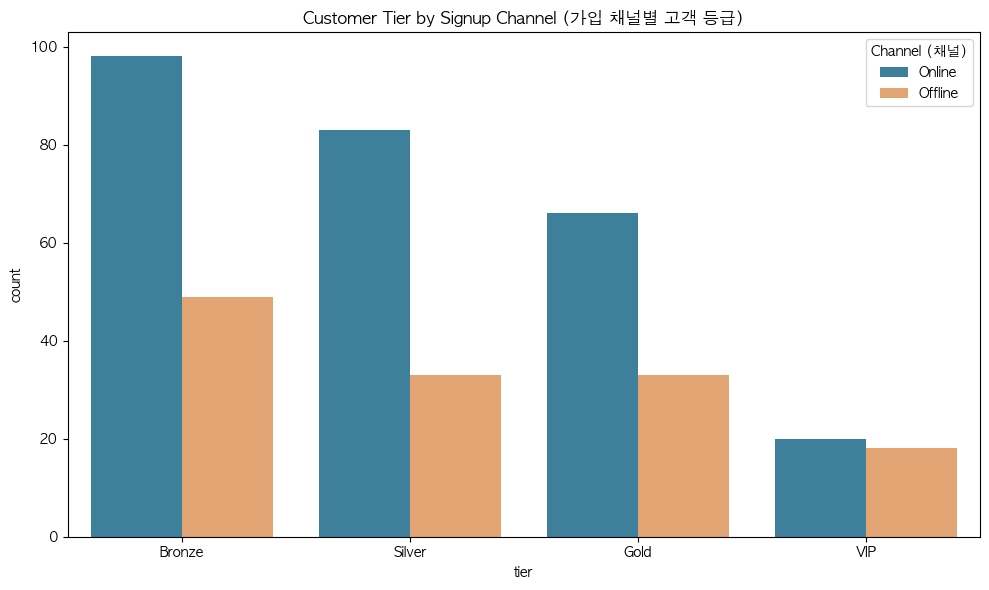

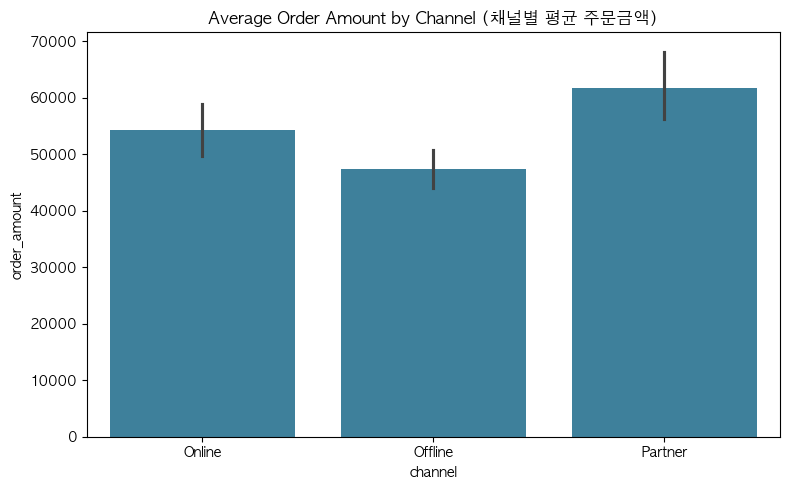

In [2]:
# 1) hue: split each category into sub-groups with color
# hue: 각 범주를 다시 색상으로 하위 그룹화
np.random.seed(42)
n = 400
tiers2 = np.random.choice(['Bronze', 'Silver', 'Gold', 'VIP'], size=n, p=[0.35, 0.3, 0.25, 0.1])
channel = np.random.choice(['Online', 'Offline'], size=n, p=[0.65, 0.35])
df2 = pd.DataFrame({'tier': tiers2, 'channel': channel})

fig, ax = plt.subplots(figsize=(10, 6))
sns.countplot(data=df2, x='tier', hue='channel', order=['Bronze', 'Silver', 'Gold', 'VIP'],
              palette=['#2E86AB', '#F4A261'], ax=ax)
ax.set_title('Customer Tier by Signup Channel (가입 채널별 고객 등급)')
ax.legend(title='Channel (채널)')
plt.tight_layout()
plt.show()

# 2) barplot: MEAN of a numeric column per category, with a 95% CI error bar
# barplot: 범주별 수치형 컬럼의 평균(신뢰구간 에러바 포함)
channels = np.repeat(['Online', 'Offline', 'Partner'], 50)
amounts = np.concatenate([
    np.random.normal(55000, 15000, 50),
    np.random.normal(48000, 12000, 50),
    np.random.normal(62000, 20000, 50),
])
df3 = pd.DataFrame({'channel': channels, 'order_amount': amounts})

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=df3, x='channel', y='order_amount', color='#2E86AB', ax=ax, errorbar='ci')
ax.set_title('Average Order Amount by Channel (채널별 평균 주문금액)')
plt.tight_layout()
plt.show()

---
# 🧪 Small Examples (예제)

## Example 1 — countplot: Membership Tier by Signup Channel (가입 채널별 회원 등급 분포)

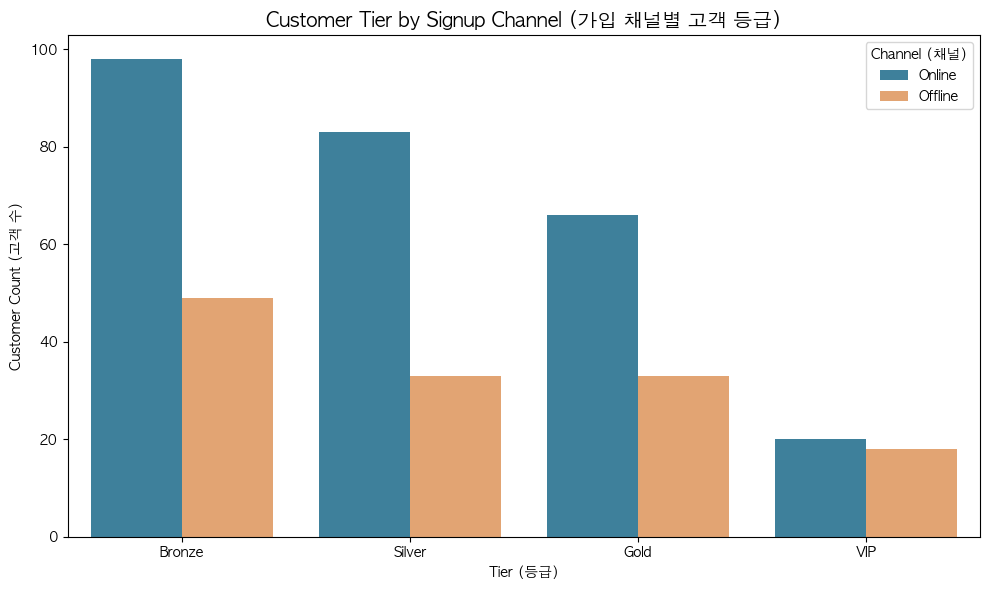

Online signup ratio by tier (등급별 온라인 가입 비중, %):
tier
Silver    71.6
Bronze    66.7
Gold      66.7
VIP       52.6
Name: Online, dtype: float64


In [10]:
# Business question: How does membership tier distribution differ
# between online and offline signups?
# 비즈니스 질문: 온라인·오프라인 가입 채널에 따라 회원 등급 분포가 어떻게 다른가?

np.random.seed(42)
n = 400
tiers = np.random.choice(['Bronze', 'Silver', 'Gold', 'VIP'], size=n, p=[0.35, 0.3, 0.25, 0.1])
channel = np.random.choice(['Online', 'Offline'], size=n, p=[0.65, 0.35])
df = pd.DataFrame({'tier': tiers, 'channel': channel})

fig, ax = plt.subplots(figsize=(10, 6))
sns.countplot(data=df, x='tier', hue='channel', order=['Bronze', 'Silver', 'Gold', 'VIP'],
              palette=['#2E86AB', '#F4A261'], ax=ax)
ax.set_title('Customer Tier by Signup Channel (가입 채널별 고객 등급)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tier (등급)')
ax.set_ylabel('Customer Count (고객 수)')
ax.legend(title='Channel (채널)')
plt.tight_layout()
plt.show()

# Turn the visual impression into an exact number with pd.crosstab
# pd.crosstab으로 시각적 인상을 정확한 숫자로 확인
online_ratio = (pd.crosstab(df['tier'], df['channel'], normalize='index')['Online']
                 .sort_values(ascending=False) * 100)
print("Online signup ratio by tier (등급별 온라인 가입 비중, %):")
print(online_ratio.round(1))

## Example 2 — barplot: Average Spend by Channel x Tier (채널×등급별 평균 지출)

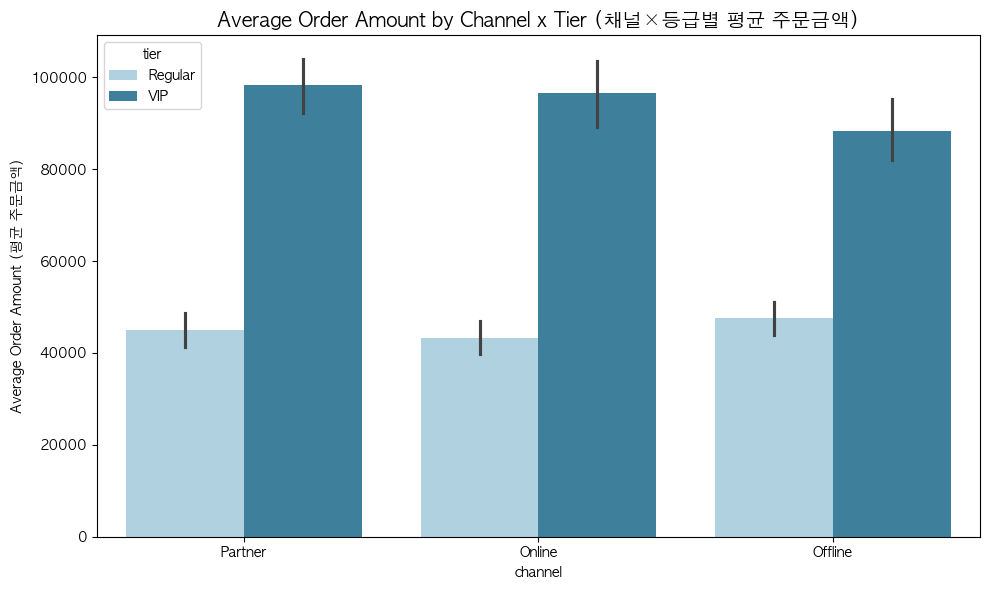

VIP premium over Regular, by channel (채널별 VIP 프리미엄, %):
  Online: +122.8%
  Partner: +118.0%
  Offline: +85.6%


In [4]:
# Business question: Do VIP customers spend more than regular customers,
# and does that premium differ by channel?
# 비즈니스 질문: VIP 고객이 일반 고객보다 더 지출하는가, 그 격차는 채널마다 다른가?

np.random.seed(42)
n = 300
channels = np.random.choice(['Online', 'Offline', 'Partner'], size=n)
tiers = np.random.choice(['Regular', 'VIP'], size=n, p=[0.7, 0.3])
base_amount = np.where(tiers == 'VIP', 90000, 45000)
amounts = base_amount + np.random.normal(0, 15000, n)
df = pd.DataFrame({'channel': channels, 'tier': tiers, 'order_amount': amounts})

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=df, x='channel', y='order_amount', hue='tier',
            palette=['#A8D5E8', '#2E86AB'], ax=ax, errorbar='ci')
ax.set_title('Average Order Amount by Channel x Tier (채널×등급별 평균 주문금액)',
              fontsize=14, fontweight='bold')
ax.set_ylabel('Average Order Amount (평균 주문금액)')
plt.tight_layout()
plt.show()

vip_premium = {}
for ch in df['channel'].unique():
    vip_avg = df[(df['channel'] == ch) & (df['tier'] == 'VIP')]['order_amount'].mean()
    reg_avg = df[(df['channel'] == ch) & (df['tier'] == 'Regular')]['order_amount'].mean()
    vip_premium[ch] = (vip_avg - reg_avg) / reg_avg * 100

print("VIP premium over Regular, by channel (채널별 VIP 프리미엄, %):")
for ch, prem in sorted(vip_premium.items(), key=lambda x: -x[1]):
    print(f"  {ch}: +{prem:.1f}%")

## Example 3 — lineplot: Monthly Sales Trend, Online vs Offline (온라인 vs 오프라인 월별 매출 추이)

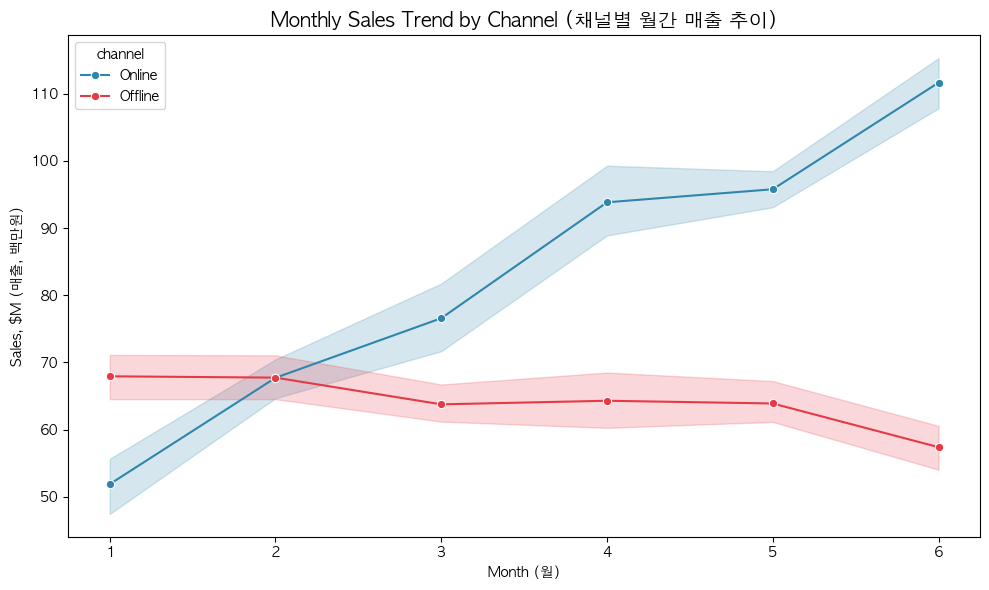

Online overtook Offline in month: 3
온라인이 오프라인을 역전한 시점: 3월


In [5]:
# Business question: Has the online channel overtaken offline in monthly
# sales, and if so, when?
# 비즈니스 질문: 온라인 채널이 오프라인을 월별 매출에서 앞서기 시작했는가, 언제인가?

np.random.seed(42)
months = list(range(1, 7)) * 30
channel_list = np.random.choice(['Online', 'Offline'], size=180)
base_online = [55, 65, 75, 88, 98, 115]
base_offline = [70, 68, 65, 63, 60, 58]
sales = []
for m, ch in zip(months, channel_list):
    base = base_online[m - 1] if ch == 'Online' else base_offline[m - 1]
    sales.append(base + np.random.normal(0, 8))
df = pd.DataFrame({'month': months, 'channel': channel_list, 'sales': sales})

fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(data=df, x='month', y='sales', hue='channel', marker='o',
             palette=['#2E86AB', '#E63946'], ax=ax)
ax.set_title('Monthly Sales Trend by Channel (채널별 월간 매출 추이)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month (월)')
ax.set_ylabel('Sales, $M (매출, 백만원)')
plt.tight_layout()
plt.show()

monthly_avg = df.groupby(['month', 'channel'])['sales'].mean().unstack()
crossover_month = None
for m in range(1, 7):
    if monthly_avg.loc[m, 'Online'] > monthly_avg.loc[m, 'Offline']:
        crossover_month = m
        break
print(f"Online overtook Offline in month: {crossover_month}")
print(f"온라인이 오프라인을 역전한 시점: {crossover_month}월")

## Example 4 — heatmap: Orders by Day x Time Slot (요일×시간대별 주문 건수)

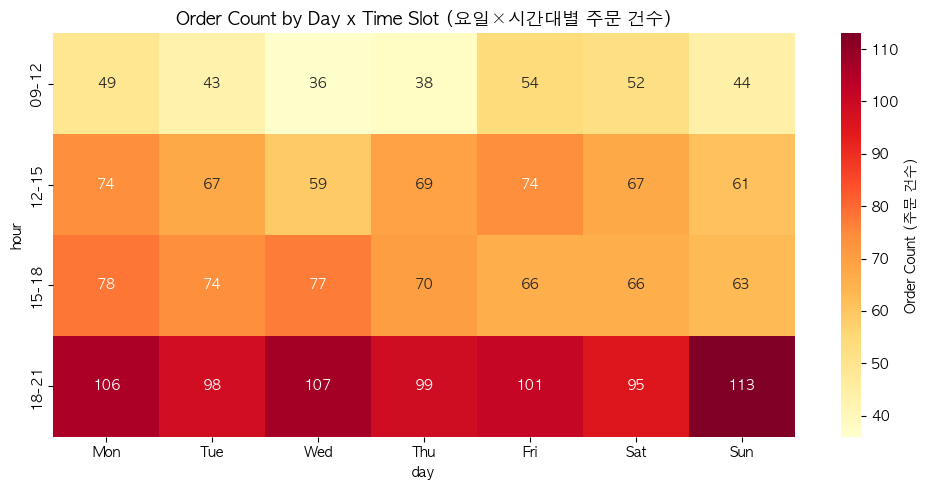

Peak time slot: Sun 18-21 (113 orders)
피크 시간대: Sun요일 18-21 (113건)


In [16]:
# Business question: Which day-of-week x time-of-day combination gets
# the most orders?
# 비즈니스 질문: 어느 요일×시간대 조합에 주문이 가장 많이 몰리는가?

np.random.seed(42)
n = 2000
days_list = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
hours_list = ['09-12', '12-15', '15-18', '18-21']
day_choice = np.random.choice(days_list, size=n)
hour_choice = np.random.choice(hours_list, size=n, p=[0.15, 0.25, 0.25, 0.35])
df = pd.DataFrame({'day': day_choice, 'hour': hour_choice})  # one row = one order

pivot = df.pivot_table(index='hour', columns='day', aggfunc='size', fill_value=0)
pivot = pivot[days_list].reindex(hours_list)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
            cbar_kws={'label': 'Order Count (주문 건수)'})
ax.set_title('Order Count by Day x Time Slot (요일×시간대별 주문 건수)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

peak = pivot.stack().idxmax()
print(f"Peak time slot: {peak[1]} {peak[0]} ({pivot.stack().max()} orders)")
print(f"피크 시간대: {peak[1]}요일 {peak[0]} ({pivot.stack().max()}건)")

## Example 5 — Practice: Apply All Four Chart Types (연습: 네 가지 차트 유형 모두 적용하기)

Fill in every `________` blank below. The cell runs with **no errors** even if you leave blanks — it just prints a reminder instead of drawing that part's chart. Once a part is filled in correctly, its chart appears immediately on re-run.

아래 `________` 빈칸을 모두 채워보세요. 빈칸을 두어도 셀은 **에러 없이** 실행되며, 그 부분의 차트 대신 안내 메시지만 출력됩니다. 파트를 올바르게 채우고 다시 실행하면 즉시 차트가 나타납니다.

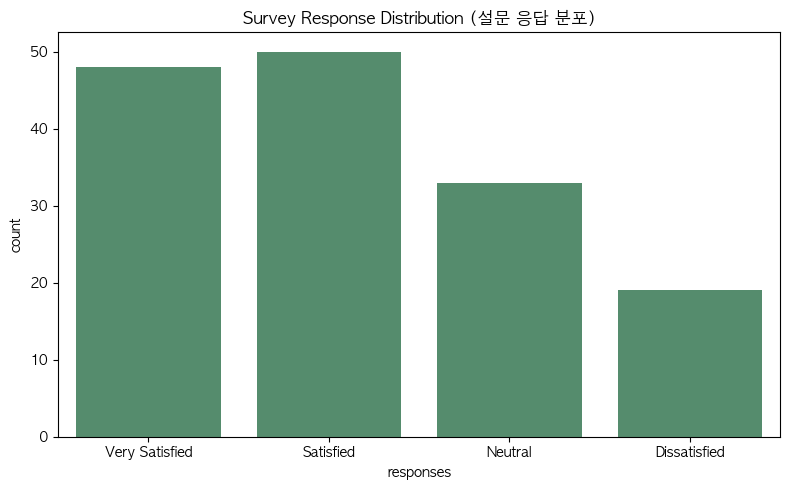

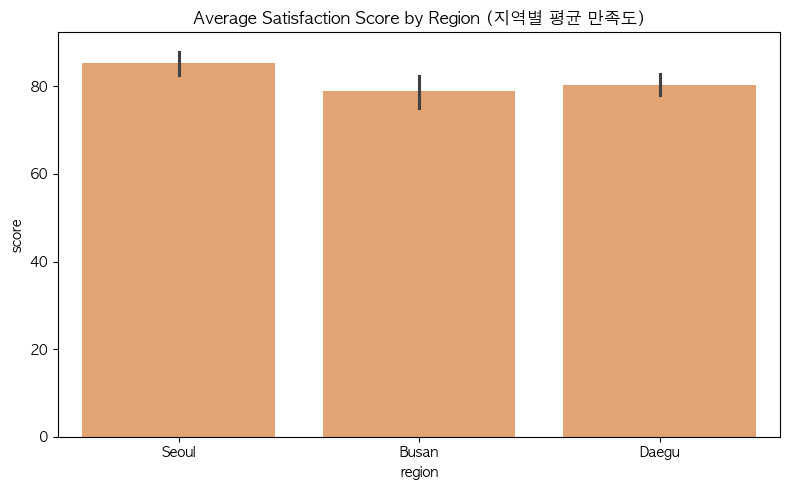

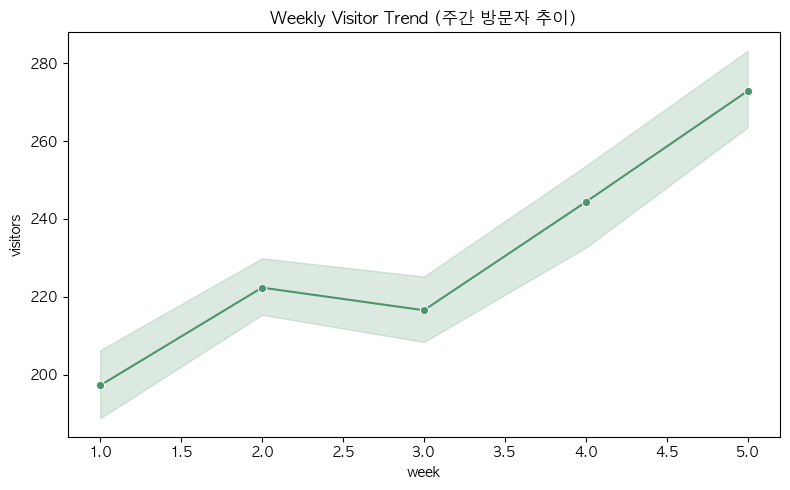

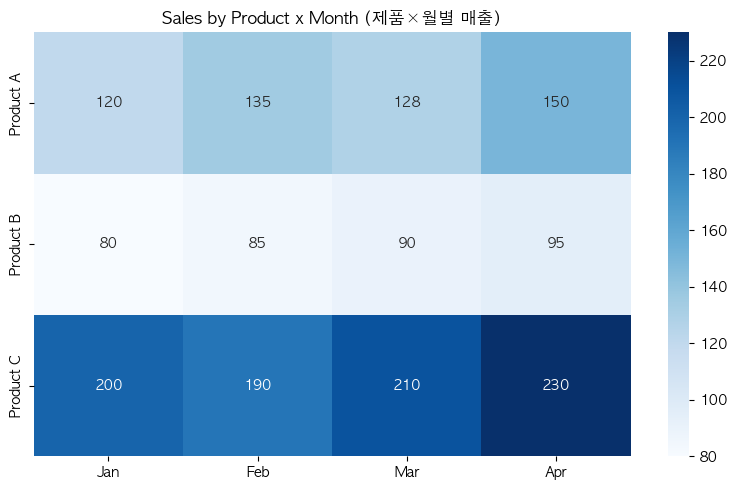

In [18]:
# ============================================================
# Practice — fill in every ________ blank, then re-run the cell
# 연습 — 아래 ________ 빈칸을 모두 채운 뒤 셀을 다시 실행하세요
# ============================================================
BLANK = "________"

def ready(*vals):
    return all(v != BLANK for v in vals)

# ---------- Part A: countplot -- survey responses ----------
np.random.seed(5)
responses = np.random.choice(['Very Satisfied', 'Satisfied', 'Neutral', 'Dissatisfied'],
                              size=150, p=[0.3, 0.4, 0.2, 0.1])

col_a   = "responses"   # TODO: column name to hold `responses` in the DataFrame
order_a = ['Very Satisfied', 'Satisfied', 'Neutral', 'Dissatisfied']   # TODO: list of the 4 categories in a sensible logical order

if ready(col_a, order_a):
    df_a = pd.DataFrame({col_a: responses})
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.countplot(data=df_a, x=col_a, order=order_a, color='#4C956C', ax=ax)
    ax.set_title('Survey Response Distribution (설문 응답 분포)')
    plt.tight_layout()
    plt.show()
else:
    print("Part A \u270f\ufe0f  Fill in col_a and order_a above, then re-run.")

# ---------- Part B: barplot -- regional satisfaction ----------
np.random.seed(8)
regions = np.repeat(['Seoul', 'Busan', 'Daegu'], 40)
scores = np.concatenate([
    np.random.normal(85, 8, 40),
    np.random.normal(78, 10, 40),
    np.random.normal(80, 7, 40),
])
df_b = pd.DataFrame({'region': regions, 'score': scores})

seaborn_func_b = "barplot"   # TODO: which sns function shows the MEAN of a numeric column per category?
color_b        = "#F4A261"   # TODO: any hex color string, e.g. '#F4A261'

if ready(seaborn_func_b, color_b):
    fig, ax = plt.subplots(figsize=(8, 5))
    getattr(sns, seaborn_func_b)(data=df_b, x='region', y='score', color=color_b, ax=ax)
    ax.set_title('Average Satisfaction Score by Region (지역별 평균 만족도)')
    plt.tight_layout()
    plt.show()
else:
    print("Part B \u270f\ufe0f  Fill in seaborn_func_b and color_b above, then re-run.")

# ---------- Part C: lineplot -- weekly visitors ----------
np.random.seed(11)
weeks = np.tile(range(1, 6), 15)
visits = np.tile([200, 220, 210, 250, 270], 15) + np.random.normal(0, 20, 75)
df_c = pd.DataFrame({'week': weeks, 'visitors': visits})

x_col_c  = "week"   # TODO: which column goes on the x-axis?
y_col_c  = "visitors"   # TODO: which column goes on the y-axis?
marker_c = "o"   # TODO: marker style string, e.g. 'o'

if ready(x_col_c, y_col_c, marker_c):
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.lineplot(data=df_c, x=x_col_c, y=y_col_c, marker=marker_c, color='#4C956C', ax=ax)
    ax.set_title('Weekly Visitor Trend (주간 방문자 추이)')
    plt.tight_layout()
    plt.show()
else:
    print("Part C \u270f\ufe0f  Fill in x_col_c, y_col_c, and marker_c above, then re-run.")

# ---------- Part D: heatmap -- product x month sales ----------
products = ['Product A', 'Product B', 'Product C']
months = ['Jan', 'Feb', 'Mar', 'Apr']
data_d = pd.DataFrame(
    [[120, 135, 128, 150], [80, 85, 90, 95], [200, 190, 210, 230]],
    index=products, columns=months
)

show_numbers_d = True   # TODO: True/False -- should each cell show its number?
cmap_d         = "Blues"   # TODO: a seaborn/matplotlib colormap name, e.g. 'Blues'

if ready(show_numbers_d, cmap_d):
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.heatmap(data_d, annot=show_numbers_d, fmt='d', cmap=cmap_d, ax=ax)
    ax.set_title('Sales by Product x Month (제품×월별 매출)')
    plt.tight_layout()
    plt.show()
else:
    print("Part D \u270f\ufe0f  Fill in show_numbers_d and cmap_d above, then re-run.")

---
# ⚠️ Common Mistakes (자주 하는 실수)

### Mistake 1 — Forgetting `order=` for Ordered Categories (순서가 있는 범주에 order= 빠뜨리기)
Without `order=`, Seaborn arranges bars by first-appearance order or frequency, not logical order — categories like Bronze → Silver → Gold → VIP can come out scrambled.  
order=를 지정하지 않으면 Seaborn은 등장 순서나 빈도순으로 막대를 배치합니다 — 브론즈→실버→골드→VIP 같은 논리적 순서가 뒤죽박죽될 수 있습니다.

✅ **Fix / 해결:** Always pass `order=['Bronze', 'Silver', 'Gold', 'VIP']` explicitly.

### Mistake 2 — Using `countplot` on Already-Aggregated Data (이미 집계된 데이터에 countplot 사용)
`countplot` counts *rows*. If your data already has a "count" or "amount" column (one row per group, not per record), `countplot` counts the number of groups, not the values inside them — a meaningless chart.  
countplot은 "행의 개수"를 셉니다. 이미 집계된 데이터(그룹 단위)에 쓰면 실제 값이 아니라 그룹의 개수가 세어져 엉뚱한 결과가 나옵니다.

✅ **Fix / 해결:** Use `barplot` (or Matplotlib's `ax.bar()`) for pre-aggregated data; reserve `countplot` for raw, one-row-per-observation data.

### Mistake 3 — Assuming `barplot` Shows a Sum (barplot이 합계를 보여준다고 착각)
`barplot`'s default statistic is the **mean**, not the sum. Reading it as "total sales" when it's actually "average sales" leads to wrong conclusions in a report.  
barplot의 기본 통계량은 합계가 아니라 **평균**입니다. 실제로는 평균인데 "총 매출"로 잘못 해석하면 보고서 오류로 이어집니다.

✅ **Fix / 해결:** Set `estimator=sum` explicitly if you need a total; otherwise remember the bar height is a mean with a confidence-interval error bar.

### Mistake 4 — Passing the Same Column to Both `x=` and `hue=` (x=와 hue=에 같은 컬럼 지정)
If `x=` and `hue=` point to the same column, Seaborn draws a redundant, confusing chart with no real second dimension.  
x=와 hue=에 같은 컬럼을 지정하면 의미 없이 중복된 혼란스러운 차트가 그려집니다.

✅ **Fix / 해결:** `x=` and `hue=` should always be two *different* categorical columns.

### Mistake 5 — Missing Combinations Show Up as Blank Heatmap Cells (누락된 조합이 히트맵의 빈 칸으로 표시됨)
If a pivot table has no data for some category combination, that cell becomes `NaN` and renders as an empty (often gray) square — easy to mistake for "zero" or a rendering bug.  
피벗 테이블에 특정 조합의 데이터가 없으면 그 칸은 NaN이 되어 빈 칸으로 표시되며, "0"이나 렌더링 버그로 오해하기 쉽습니다.

✅ **Fix / 해결:** Use `pivot_table(..., fill_value=0)` to make missing combinations explicitly zero.

### Mistake 6 — Skipping the Colorbar Label (컬러바 라벨 생략)
A heatmap's color scale means nothing to a reader unless they know what it represents — counts? revenue? a percentage?  
히트맵의 색상 스케일은 그것이 무엇을 나타내는지(건수? 금액? 비율?) 모르면 독자에게 아무 의미가 없습니다.

✅ **Fix / 해결:** Always pass `cbar_kws={'label': 'unit and meaning'}` to `sns.heatmap()`.

---
# 💡 Tips (팁)
Useful tips or shortcuts / 유용한 팁과 단축법

- Seaborn functions return a Matplotlib `Axes`, so `ax.set_title()`, `ax.grid()`, `plt.tight_layout()` all keep working — "draw fast with Seaborn, polish with Matplotlib."  
Seaborn 함수는 Matplotlib Axes를 반환하므로 ax.set_title(), ax.grid(), plt.tight_layout()을 그대로 사용할 수 있습니다 — "Seaborn으로 빠르게 그리고 Matplotlib으로 다듬는다."
- Combine `pd.crosstab(..., normalize='index')` with `countplot`/`barplot` to turn a visual impression into an exact percentage for your report.  
pd.crosstab(..., normalize='index')를 countplot/barplot과 함께 쓰면 시각적 인상을 보고서용 정확한 비율로 바꿀 수 있습니다.
- `hue=` is Seaborn's one-parameter answer to what used to take manual bar-width offsets in Matplotlib grouped bars.  
hue=는 Matplotlib 그룹 막대에서 수동으로 계산하던 막대 폭·오프셋을 파라미터 하나로 대신합니다.
- When a heatmap's row/column order looks wrong, it's almost always because `pivot_table()` sorted alphabetically — re-index with your own ordered list.  
히트맵의 행·열 순서가 이상하다면 거의 항상 pivot_table()이 알파벳/가나다순으로 정렬했기 때문입니다 — 원하는 순서 리스트로 다시 reindex하세요.
- A wide confidence-interval error bar on a `barplot` is itself a finding: that group's average is less reliable (small sample or high variance) — worth flagging in the write-up.  
barplot의 넓은 신뢰구간 에러바 자체가 하나의 발견입니다: 그 그룹의 평균 추정이 불안정하다(표본이 적거나 편차가 큼)는 뜻이므로 보고서에 언급할 가치가 있습니다.

---
# 🔗 Related Concepts (관련 개념)

```
Matplotlib (Sections 2-9)
        ↓
Seaborn Basics (Section 10)  ← you are here / 현재 위치
   countplot / barplot / lineplot / heatmap
        ↓
Seaborn Advanced (Section 11)
   pairplot / FacetGrid / regplot / jointplot
        ↓
Styling & Export (Section 12)
        ↓
Plotly (Sections 13-14)
        ↓
Tableau Public (Sections 15-17)
```

*How is today's topic connected to other concepts?*

**EN:** Everything you built by hand in Matplotlib (Sections 2-9) — manual `groupby()` then `ax.bar()`, manual `ax.imshow()` heatmaps with nested loops for labels — is exactly what Seaborn automates here. The next section (11) builds on this same "Axes-level" pattern (`ax=` parameter) but introduces "Figure-level" functions (`pairplot`, `FacetGrid`) that create their own multi-panel layouts — a different mental model worth contrasting directly against today's material.

**KR:** Matplotlib(섹션 2~9)에서 직접 만들었던 모든 것 — groupby() 후 ax.bar()로 직접 그리기, 이중 반복문으로 라벨을 찍던 수동 ax.imshow() 히트맵 — 이 바로 오늘 배운 Seaborn이 자동화한 부분입니다. 다음 섹션(11)은 오늘과 같은 "Axes-level" 패턴(ax= 파라미터)을 기반으로 하지만, 스스로 여러 패널 레이아웃을 만드는 "Figure-level" 함수(pairplot, FacetGrid)를 소개하므로 오늘 내용과 직접 대조해서 이해할 가치가 있습니다.

---
# 💼 Business Example (비즈니스 예시)
*How would a Business Analyst use this?*

**Scenario / 시나리오:**

**EN:** You're a BA at a subscription e-commerce company. Leadership wants a quick read on the membership program ahead of next quarter's budget planning: how many customers are in each tier, and is the VIP tier actually spending enough more to justify its perks budget?

**KR:** 당신은 구독형 이커머스 회사의 BA입니다. 경영진은 다음 분기 예산 계획에 앞서 멤버십 프로그램을 빠르게 파악하고 싶어합니다: 등급별 고객 수는 몇 명이고, VIP 등급이 실제로 혜택 예산을 정당화할 만큼 더 지출하고 있는가?

**To-do / 할 일:**
- [x] Count customers per tier with `countplot` on raw, one-row-per-customer data  
countplot으로 등급별 고객 수 세기 (원본, 고객당 한 행 데이터)
- [x] Compare average spend per tier with `barplot` and inspect the confidence interval  
barplot으로 등급별 평균 지출을 비교하고 신뢰구간 확인하기
- [x] Compute the exact VIP spending premium as a percentage, not just eyeball the chart  
차트만 보지 말고 VIP 지출 프리미엄을 정확한 퍼센트로 계산하기
- [x] Write a one-line recommendation leadership can act on  
경영진이 바로 실행할 수 있는 한 줄 제안 작성하기

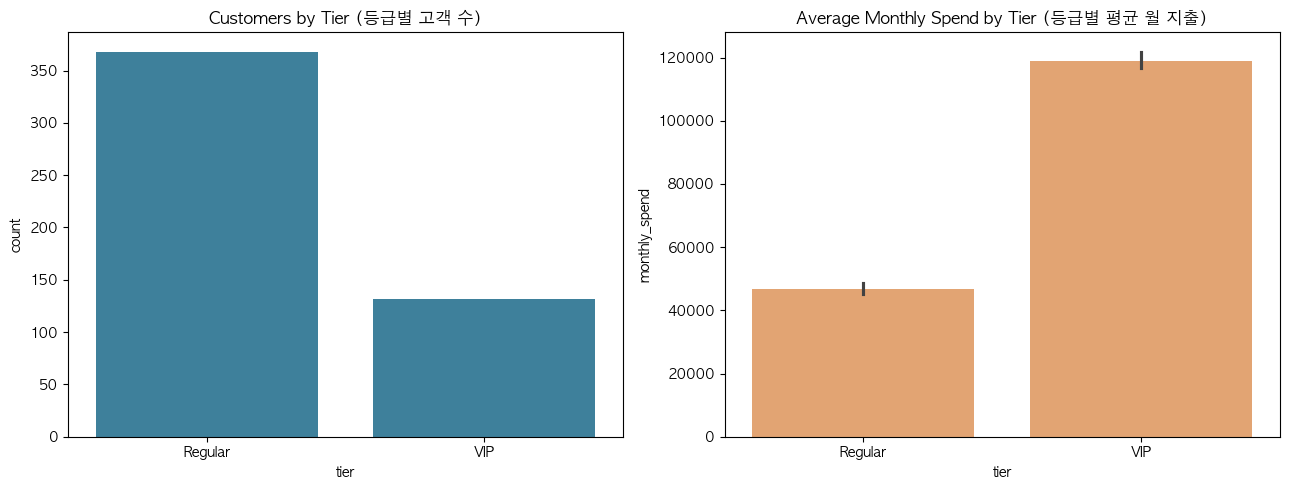

VIP customers: 132 (26.4% of total)
VIP 고객: 132명 (전체의 26.4%)
VIP spends 153.7% more per month than Regular, on average.
VIP는 평균적으로 Regular보다 월 지출이 153.7% 더 많습니다.
Recommendation: the VIP premium comfortably covers a modest perks budget increase.
제안: VIP 프리미엄은 소폭의 혜택 예산 증액을 감당할 만큼 충분합니다.


In [19]:
np.random.seed(7)
n = 500
tiers = np.random.choice(['Regular', 'VIP'], size=n, p=[0.75, 0.25])
spend = np.where(tiers == 'VIP', 120000, 48000) + np.random.normal(0, 18000, n)
df = pd.DataFrame({'tier': tiers, 'monthly_spend': spend})

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.countplot(data=df, x='tier', order=['Regular', 'VIP'], color='#2E86AB', ax=axes[0])
axes[0].set_title('Customers by Tier (등급별 고객 수)')

sns.barplot(data=df, x='tier', y='monthly_spend', order=['Regular', 'VIP'],
            color='#F4A261', ax=axes[1], errorbar='ci')
axes[1].set_title('Average Monthly Spend by Tier (등급별 평균 월 지출)')

plt.tight_layout()
plt.show()

vip_count = (df['tier'] == 'VIP').sum()
vip_share = vip_count / len(df) * 100
vip_avg = df[df['tier'] == 'VIP']['monthly_spend'].mean()
reg_avg = df[df['tier'] == 'Regular']['monthly_spend'].mean()
premium = (vip_avg - reg_avg) / reg_avg * 100

print(f"VIP customers: {vip_count} ({vip_share:.1f}% of total)")
print(f"VIP 고객: {vip_count}명 (전체의 {vip_share:.1f}%)")
print(f"VIP spends {premium:.1f}% more per month than Regular, on average.")
print(f"VIP는 평균적으로 Regular보다 월 지출이 {premium:.1f}% 더 많습니다.")
print("Recommendation: the VIP premium comfortably covers a modest perks budget increase.")
print("제안: VIP 프리미엄은 소폭의 혜택 예산 증액을 감당할 만큼 충분합니다.")

---
# 📝 Summary (요약)
*Write today's concept in 3~5 sentences.*

**EN:** Seaborn is a statistical plotting library built on Matplotlib that trades manual aggregation and styling for a DataFrame-first, column-name-based API. `countplot` counts rows per category, `barplot` shows a mean (with a confidence interval) per category, `lineplot` averages repeated y-values at each x and shades their spread, and `heatmap` turns a 2D DataFrame (ideally a pivot table) into a color grid with automatic axis labels. Because every one of these is an "Axes-level" function, they accept `ax=` and return objects you can keep customizing with familiar Matplotlib syntax. The recurring practical gotchas are all about defaults: unordered categories, mean-vs-sum confusion, and missing combinations showing up as blanks.

**KR:** Seaborn은 Matplotlib 위에 구축된 통계 시각화 라이브러리로, 수동 집계·스타일링 대신 DataFrame과 컬럼명 기반의 API를 제공합니다. countplot은 범주별 행의 개수를, barplot은 범주별 평균(신뢰구간 포함)을, lineplot은 같은 x값의 반복된 y값을 평균 내고 그 흩어짐을 음영으로, heatmap은 2차원 DataFrame(이상적으로는 피벗 테이블)을 자동 축 라벨이 붙은 색상 격자로 바꿔줍니다. 이 네 함수 모두 "Axes-level" 함수이므로 ax=를 받고, 이후 익숙한 Matplotlib 문법으로 계속 다듬을 수 있습니다. 반복적으로 나타나는 실무적 함정은 대부분 기본값과 관련이 있습니다: 정렬되지 않은 범주, 평균과 합계의 혼동, 그리고 빈 칸으로 나타나는 누락된 조합입니다.

---
# 📌 One Sentence Summary (한 문장 요약)
Today's topic in ONE sentence. / 오늘의 주제를 한 문장으로.

> **EN:** Seaborn turns raw, row-per-record data into aggregated, presentation-ready charts (counts, means with confidence intervals, trends, and heatmaps) with a DataFrame-and-column-name API, while still handing you back a Matplotlib `Axes` to fine-tune.

> **KR:** Seaborn은 DataFrame과 컬럼명만으로 원본(행 단위) 데이터를 집계된 발표용 차트(개수, 신뢰구간 포함 평균, 추세, 히트맵)로 바꿔주면서도, 세밀한 조정을 위한 Matplotlib Axes를 그대로 돌려줍니다.

---
# ❓ Review Questions (복습 질문)

**Q1 (EN).** Why does `sns.countplot(data=df, x='tier')` sometimes draw bars in a strange order, and how do you fix it?
**Q1 (KR).** `sns.countplot(data=df, x='tier')`가 막대를 이상한 순서로 그리는 이유는 무엇이며, 어떻게 고칠 수 있나요?

Without order=, bars follow first-appearance or frequency, not logical rank. Pass order= explicitly.  
순서가 없으니 order=로 직접 정해 주세요.

**Q2 (EN).** What statistic does `barplot` show by default, and what parameter changes it to a total?
**Q2 (KR).** `barplot`은 기본적으로 어떤 통계량을 보여주며, 합계로 바꾸려면 어떤 파라미터를 사용해야 하나요?

barplot defaults to the mean; estimator=sum switches it to a total.  
기본은 평균, 합계는 estimator=sum입니다.

**Q3 (EN).** In `sns.lineplot(data=df, x='day', y='sales')`, what does the shaded band around the line represent?
**Q3 (KR).** `sns.lineplot(data=df, x='day', y='sales')`에서 선 주변의 음영은 무엇을 나타내나요?

The band is a confidence interval around the mean of repeated y-values at each x.  
같은 x에 y가 여러 개일 때, 선=평균, 음영=신뢰구간입니다.

**Q4 (EN).** Why should you call `pivot_table(..., fill_value=0)` before feeding data into `sns.heatmap()`?
**Q4 (KR).** `sns.heatmap()`에 데이터를 넣기 전에 왜 `pivot_table(..., fill_value=0)`을 호출해야 하나요?

Missing row×column combos become NaN blanks; fill_value=0 makes them true zeros.  
빈 칸을 0으로 채워, 누락과 진짜 0을 헷갈리지 않게 합니다.

**Q5 (EN).** Why do all four functions in this section (`countplot`, `barplot`, `lineplot`, `heatmap`) accept an `ax=` parameter, and what does that let you do?
**Q5 (KR).** 이 섹션의 네 함수(countplot, barplot, lineplot, heatmap) 모두 ax= 파라미터를 받는 이유는 무엇이며, 이를 통해 무엇을 할 수 있나요?

They are Axes-level: ax= puts the chart on a subplot you already made.  
대시보드의 특정 패널에 그리려고 ax=를 받습니다.
---
*📅 Try answering these again in a few days. / 며칠 후 다시 답해보세요.*